# Project Title: The Hidden Calories in Starbucks Drinks

### Data Storytelling Project
### Audience: Executive / Non-Technical Audience

Author: Abhishek Kamboj


Introduction

Starbucks is one of the most recognizable beverage brands in the world.
While many consumers associate Starbucks with coffee, many beverages
contain high levels of calories and sugar.

The objective of this analysis is to investigate nutritional trends
within Starbucks beverages and identify which drinks provide the
highest calorie and sugar content.

This analysis focuses on:
- Beverage categories
- Sugar content
- Calorie distribution
- Caffeine efficiency
- Nutritional correlations


Questions Investigated

1. Which beverage categories contain the highest calories?
2. Is there a relationship between sugar and calories?
3. What does the distribution of beverage calories look like?
4. Which beverages provide the best caffeine efficiency?
5. Are higher calorie drinks actually providing more caffeine?
6. What nutritional relationships exist among calories, sugar, fat, and caffeine?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
plt.style.use('ggplot')

In [3]:
df = pd.read_csv('starbucks_drinkMenu_expanded.csv')

In [4]:
df.head()

,Beverage_category,Beverage,Beverage_prep,Calories,Total Fat (g),Trans Fat (g),Saturated Fat (g),Sodium (mg),Total Carbohydrates (g),Cholesterol (mg),Dietary Fibre (g),Sugars (g),Protein (g),Vitamin A (% DV),Vitamin C (% DV),Calcium (% DV),Iron (% DV),Caffeine (mg)
0,Coffee,Brewed Coffee,Short,3,0.1,0.0,0.0,0,5,0,0,0,0.3,0%,0%,0%,0%,175
1,Coffee,Brewed Coffee,Tall,4,0.1,0.0,0.0,0,10,0,0,0,0.5,0%,0%,0%,0%,260
2,Coffee,Brewed Coffee,Grande,5,0.1,0.0,0.0,0,10,0,0,0,1.0,0%,0%,0%,0%,330
3,Coffee,Brewed Coffee,Venti,5,0.1,0.0,0.0,0,10,0,0,0,1.0,0%,0%,2%,0%,410
4,Classic Espresso Drinks,Caffè Latte,Short Nonfat Milk,70,0.1,0.1,0.0,5,75,10,0,9,6.0,10%,0%,20%,0%,75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Beverage_category          242 non-null    object 
 1   Beverage                   242 non-null    object 
 2   Beverage_prep              242 non-null    object 
 3   Calories                   242 non-null    int64  
 4    Total Fat (g)             242 non-null    object 
 5   Trans Fat (g)              242 non-null    float64
 6   Saturated Fat (g)          242 non-null    float64
 7    Sodium (mg)               242 non-null    int64  
 8    Total Carbohydrates (g)   242 non-null    int64  
 9   Cholesterol (mg)           242 non-null    int64  
 10   Dietary Fibre (g)         242 non-null    int64  
 11   Sugars (g)                242 non-null    int64  
 12   Protein (g)               242 non-null    float64
 13  Vitamin A (% DV)           242 non-null    object 

In [6]:
df.describe()

,Calories,Trans Fat (g),Saturated Fat (g),Sodium (mg),Total Carbohydrates (g),Cholesterol (mg),Dietary Fibre (g),Sugars (g),Protein (g)
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000
mean,193.871901,1.307025,0.037603,6.363636,128.884298,35.991736,0.805785,32.962810,6.978512
std,102.863303,1.640259,0.071377,8.630257,82.303223,20.795186,1.445944,19.730199,4.871659
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,120.000000,0.100000,0.000000,0.000000,70.000000,21.000000,0.000000,18.000000,3.000000
50%,185.000000,0.500000,0.000000,5.000000,125.000000,34.000000,0.000000,32.000000,6.000000
75%,260.000000,2.000000,0.100000,10.000000,170.000000,50.750000,1.000000,43.750000,10.000000
max,510.000000,9.000000,0.300000,40.000000,340.000000,90.000000,8.000000,84.000000,20.000000


In [7]:
df.isnull().sum()

Beverage_category            0
Beverage                     0
Beverage_prep                0
Calories                     0
 Total Fat (g)               0
Trans Fat (g)                0
Saturated Fat (g)            0
 Sodium (mg)                 0
 Total Carbohydrates (g)     0
Cholesterol (mg)             0
 Dietary Fibre (g)           0
 Sugars (g)                  0
 Protein (g)                 0
Vitamin A (% DV)             0
Vitamin C (% DV)             0
 Calcium (% DV)              0
Iron (% DV)                  0
Caffeine (mg)                1
dtype: int64

In [16]:
df.columns

Index(['Beverage_category', 'Beverage', 'Beverage_prep', 'Calories',
       'Total Fat (g)', 'Trans Fat (g)', 'Saturated Fat (g)', 'Sodium (mg)',
       'Total Carbohydrates (g)', 'Cholesterol (mg)', 'Dietary Fibre (g)',
       'Sugars (g)', 'Protein (g)', 'Vitamin A (% DV)', 'Vitamin C (% DV)',
       'Calcium (% DV)', 'Iron (% DV)', 'Caffeine (mg)'],
      dtype='object')

### Visualization 1: Highest Calorie Drink Categories

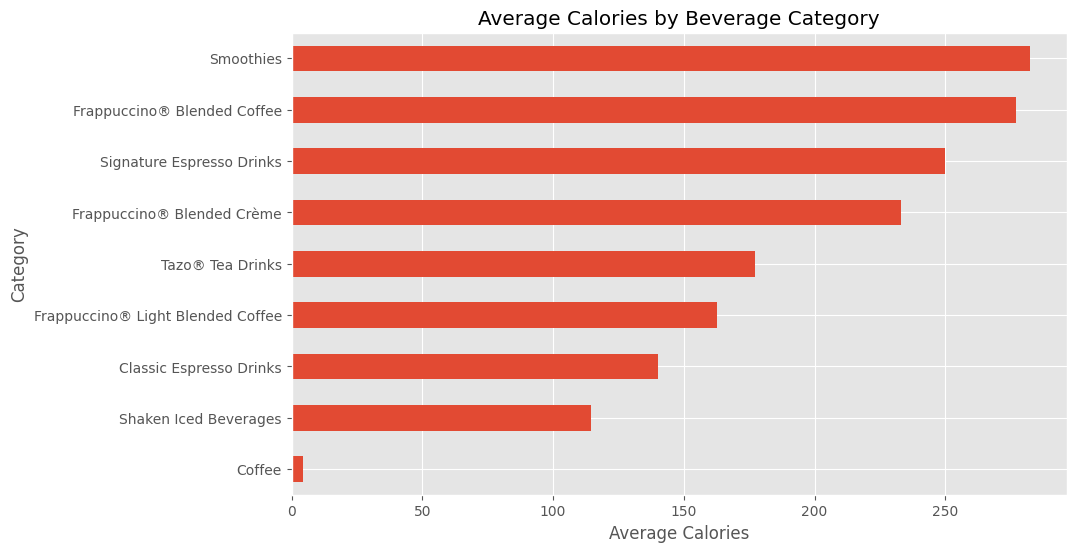

In [17]:
avg_calories = df.groupby('Beverage_category')['Calories'].mean().sort_values()

plt.figure(figsize=(10,6))
avg_calories.plot(kind='barh')

plt.title('Average Calories by Beverage Category')
plt.xlabel('Average Calories')
plt.ylabel('Category')

plt.show()

### Main Insight: Smoothies and Frappuccinos contain the highest average calories. Plain coffee contains almost no calories. One of the clearest findings is that blended beverages and smoothies dramatically exceed traditional coffee drinks in calorie content. In contrast, brewed coffee remains extremely low calorie.


##


### Visualization 2: Sugar vs Calories

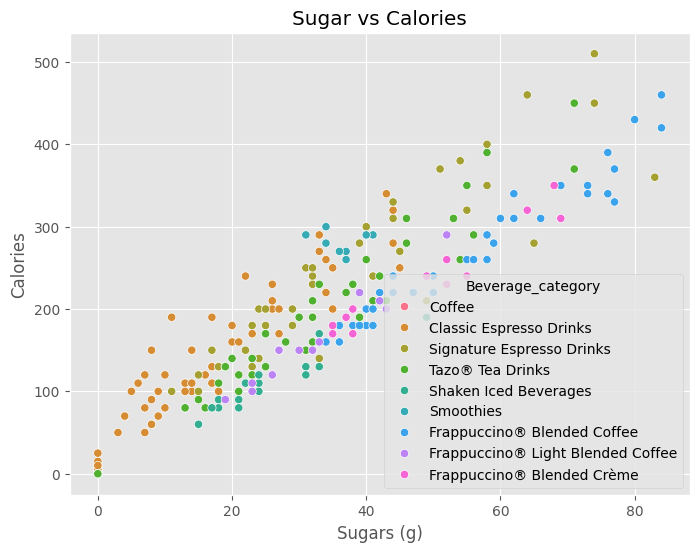

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Sugars (g)',
    y='Calories',
    hue='Beverage_category'
)

plt.title('Sugar vs Calories')
plt.show()

### Main Insight: There is a very strong positive relationship between sugar and calories. As sugar increases, calories increase almost linearly. This suggests that sugar content is the primary contributor to high-calorie beverages.

#

### Visualization 3: Distribution of Calories

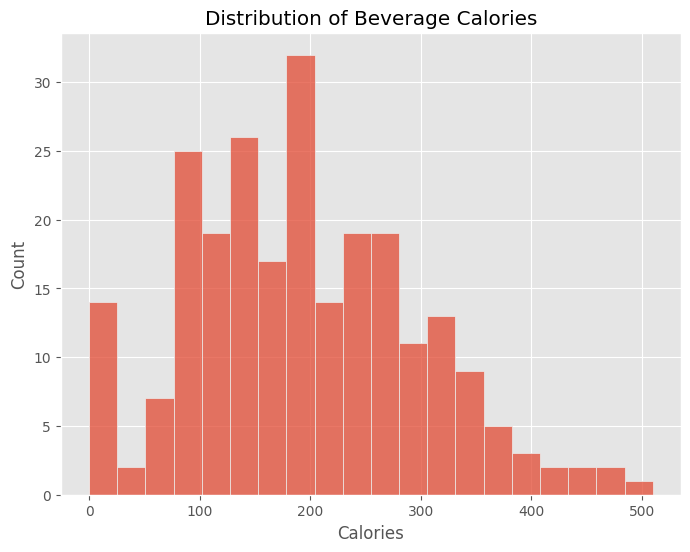

In [19]:
plt.figure(figsize=(8,6))

sns.histplot(df['Calories'], bins=20)

plt.title('Distribution of Beverage Calories')

plt.show()

### While most drinks cluster around moderate calorie ranges, several beverages exceed 400 calories, approaching the caloric content of a full meal.

##

### Visualization 4: Caffeine Efficiency

In [22]:
df['Caffeine (mg)'] = pd.to_numeric(df['Caffeine (mg)'], errors='coerce')
df['Calories'] = pd.to_numeric(df['Calories'], errors='coerce')

In [23]:
df['Caffeine_Efficiency'] = df['Caffeine (mg)'] / (df['Calories'] + 1)

top_efficiency = df.sort_values(
    by='Caffeine_Efficiency',
    ascending=False).head(10)

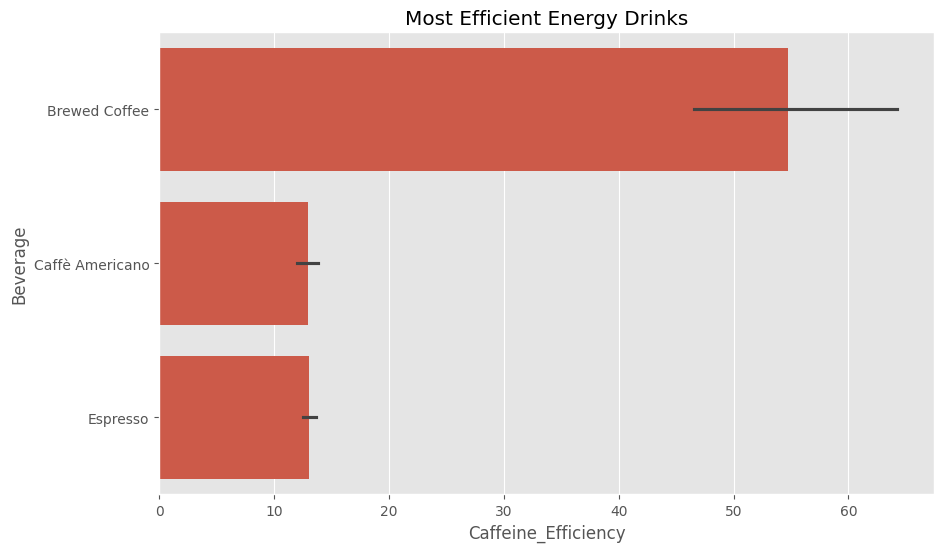

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_efficiency,
    x='Caffeine_Efficiency',
    y='Beverage'
)

plt.title('Most Efficient Energy Drinks')
plt.show()

### When evaluating caffeine efficiency, brewed coffee overwhelmingly outperformed all other beverages. This means consumers can receive similar caffeine levels with a fraction of the calories.

###


### Visualization 5: Correlation Heatmap

In [26]:
numeric_cols = [
    'Calories',
    'Sugars (g)',
    'Total Fat (g)',
    'Caffeine (mg)']

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r'[^0-9.]', '', regex=True)
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

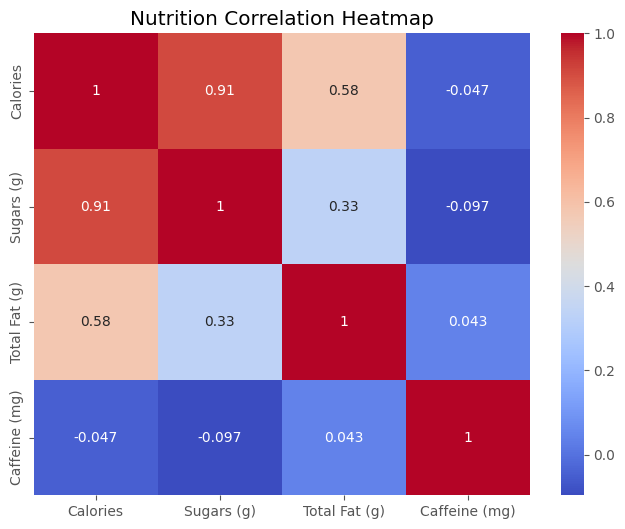

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm')

plt.title('Nutrition Correlation Heatmap')

plt.show()

### An interesting finding was that caffeine showed almost no correlation with calories. This means consumers may unintentionally consume far more sugar and calories without receiving significantly more energy.

#

## Business Recommendations: 

- Promote lower-sugar alternatives more aggressively.
- Encourage smaller default drink sizes.
- Add clearer sugar/calorie indicators on menus.

## Conclusion:

1. Blended drinks contain the highest calories.
2. Sugar is the strongest contributor to calorie content.
3. Some beverages contain meal-level calories.
4. Brewed coffee provides the best caffeine efficiency.
5. High-calorie drinks do not necessarily provide more caffeine.
